In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as funcy
import torch.optim as opti
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dev=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
data=datasets.MNIST(root='./mnist',train=True,download=True,transform=transforms.Compose([transforms.ToTensor(),]))

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.09MB/s]


In [4]:
load=DataLoader(data,batch_size=64,shuffle=True,num_workers=2)

In [5]:
class RanSinuEmb(nn.Module):
    def __init__(self,embd,scale=30):
        super().__init__()
        self.W=nn.Parameter(torch.randn(embd//2)*scale,requires_grad=False)
    def forward(self,x):
        xp=x[:,None]*self.W[None,:]*2*np.pi
        return torch.cat([torch.sin(xp),torch.cos(xp)],dim=-1)

In [6]:
class Didd(nn.Module):
    def __init__(self,inn,out):
        super().__init__()
        self.did=nn.Linear(inn,out)
    def forward(self,x):
        return self.did(x)[...,None,None]

In [7]:
class Score(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb=nn.Sequential(RanSinuEmb(embd=128),
                               nn.Linear(128,128),
                               nn.SiLU(),
                               nn.Linear(128,64),)
        self.c1=nn.Conv2d(1,32,3,padding=1)
        self.d1=Didd(64,32)
        self.c2=nn.Conv2d(32,64,3,stride=2,padding=1)
        self.d2=Didd(64,64)
        self.c3=nn.Conv2d(64,128,3,stride=2,padding=1)
        self.d3=Didd(64,128)
        self.tc3=nn.ConvTranspose2d(128,64,3,stride=2,padding=1,output_padding=1)
        self.td3=Didd(64,64)
        self.tc2=nn.ConvTranspose2d(128,32,3,stride=2,padding=1,output_padding=1)
        self.td2=Didd(64,32)
        self.fout=nn.Conv2d(64,1,3,padding=1)
        self.act=nn.SiLU()
    def forward(self,x,sig):
        embb=self.emb(torch.log(sig))
        b1=self.c1(x)
        b1+=self.d1(embb)
        b1=self.act(b1)

        b2=self.c2(b1)
        b2+=self.d2(embb)
        b2=self.act(b2)

        b3=self.c3(b2)
        b3+=self.d3(embb)
        b3=self.act(b3)

        ub3=self.tc3(b3)
        ub3+=self.td3(embb)
        ub3=self.act(ub3)

        ub2=self.tc2(torch.cat([ub3,b2],dim=1))
        ub2+=self.td2(embb)
        ub2=self.act(ub2)

        ub=torch.cat([ub2,b1],dim=1)
        out=self.fout(ub)
        return out/sig.view(-1,1,1,1)

In [8]:
def losss(mdl,x,sig):
    batch=x.shape[0]
    id=torch.randint(0,len(sig),(batch,),device=dev)
    sigu=sig[id].view(batch,1,1,1)
    z=torch.randn_like(x)
    px=x+z*sigu
    score=mdl(px,sigu.view(-1))
    tar=-z
    loss=torch.mean(torch.sum((score*sigu+z)**2,dim=(1,2,3)))
    return loss

In [9]:
Bsig,Esig,Nsig=25.0,0.01,500

In [10]:
sigs=torch.tensor(np.exp(np.linspace(np.log(Bsig),np.log(Esig),Nsig))).float().to(dev)

In [11]:
modle=Score().to(dev)
optim=opti.Adam(modle.parameters(),lr=1e-4)

In [12]:
modle.train()

Score(
  (emb): Sequential(
    (0): RanSinuEmb()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
  )
  (c1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (d1): Didd(
    (did): Linear(in_features=64, out_features=32, bias=True)
  )
  (c2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (d2): Didd(
    (did): Linear(in_features=64, out_features=64, bias=True)
  )
  (c3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (d3): Didd(
    (did): Linear(in_features=64, out_features=128, bias=True)
  )
  (tc3): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (td3): Didd(
    (did): Linear(in_features=64, out_features=64, bias=True)
  )
  (tc2): ConvTranspose2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (td2): Didd(
    (did): Linear(in_features=64

In [13]:
hloss=[]

In [14]:
for epoch in range(35):
    avloss=0
    for i,(x,_) in enumerate(load):
        x=x.to(dev)
        optim.zero_grad()
        loss=losss(modle,x,sigs)
        loss.backward()
        optim.step()
        avloss+=loss.item()
    avloss/=len(load)
    hloss.append(avloss)
    print(f'{epoch} loss: {avloss:.4f}')

0 loss: 453.5811
1 loss: 295.6501
2 loss: 267.7069
3 loss: 218.2190
4 loss: 180.7578
5 loss: 162.4664
6 loss: 151.1552
7 loss: 139.7753
8 loss: 133.1693
9 loss: 129.4863
10 loss: 124.3704
11 loss: 117.5696
12 loss: 115.4392
13 loss: 114.1984
14 loss: 109.1875
15 loss: 108.4961
16 loss: 105.4399
17 loss: 103.6491
18 loss: 103.2541
19 loss: 100.9529
20 loss: 99.9857
21 loss: 96.8573
22 loss: 96.2835
23 loss: 94.4864
24 loss: 92.9163
25 loss: 92.3802
26 loss: 92.7853
27 loss: 91.4775
28 loss: 87.5069
29 loss: 88.6770
30 loss: 87.9415
31 loss: 88.1475
32 loss: 84.0751
33 loss: 85.7284
34 loss: 83.5363


In [15]:
@torch.no_grad()
def sampling(mdl,sigs):
    mdl.eval()
    x=torch.randn(16,1,28,28).to(dev)*Bsig
    eps=2e-5
    for i,sig in enumerate(sigs):
        vsig=sig.item()
        alpha=eps*(vsig/sigs[-1].item())**2
        for _ in range(20):
            score=mdl(x,sig.view(1).repeat(x.shape[0]))
            z=torch.randn_like(x)
            x=x+(alpha/2)*score/sig+0.5*torch.sqrt(torch.tensor(alpha))*z
    return x.cpu().numpy()

In [16]:
sams=sampling(modle,sigs)

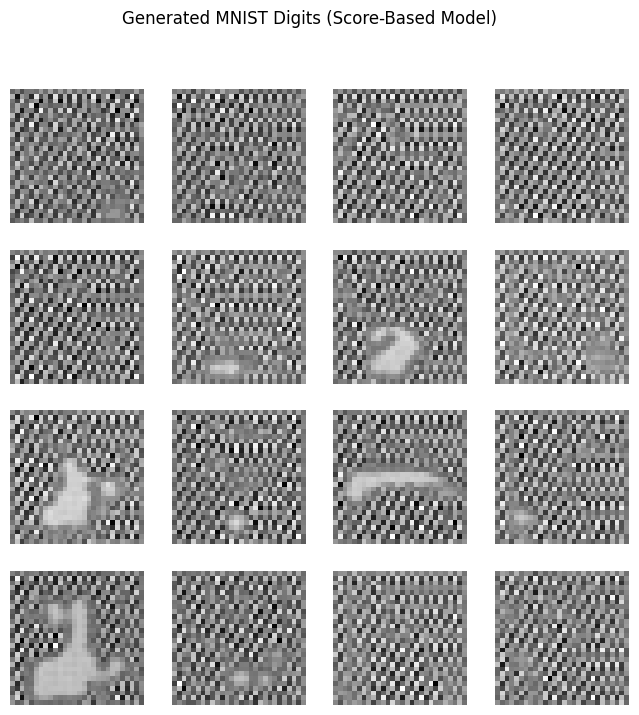

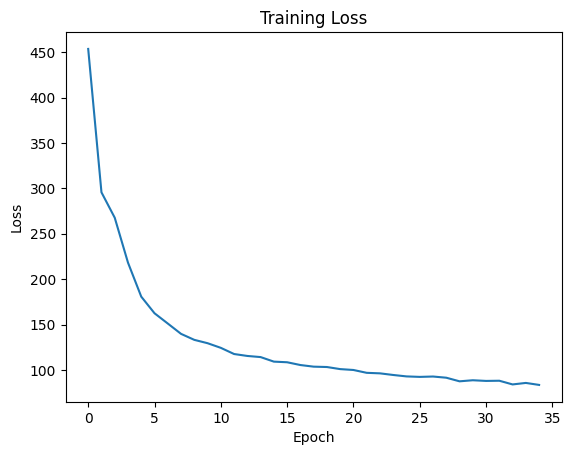

In [17]:
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(sams[i, 0], cmap='gray')
    plt.axis('off')
plt.suptitle("Generated MNIST Digits (Score-Based Model)")
plt.show()

plt.figure()
plt.plot(hloss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()